/tmp/ipykernel_148/2746980068.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  bar = patches.Rectangle((0, 0), length, width, color='lightgray', edgecolor='black')
/tmp/ipykernel_148/2746980068.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  hole = patches.Circle((x_hole, y_hole), radius, color='white', edgecolor='red')


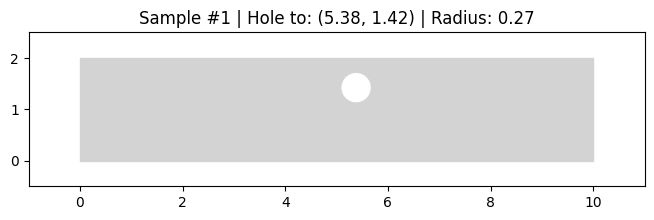

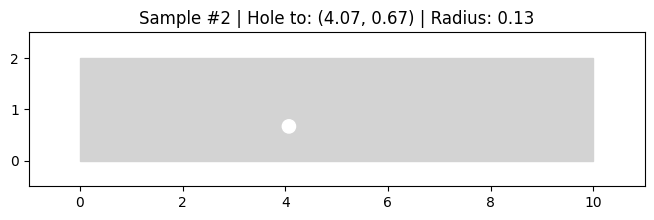

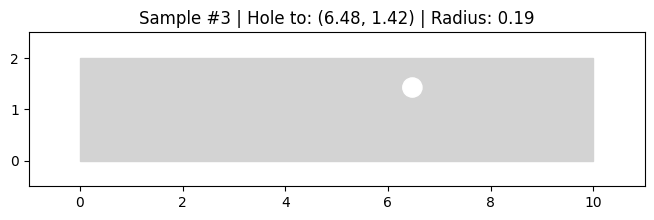

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def generate_geometry_sample(sample_id):
    # 1. Ορίζουμε τις διαστάσεις της ράβδου
    length = 10
    width = 2

    # 2. Παράγουμε τυχαία θέση και μέγεθος για την τρύπα
    # Το uniform(min, max) βγάζει έναν τυχαίο δεκαδικό αριθμό
    x_hole = random.uniform(1.5, 8.5)
    y_hole = random.uniform(0.5, 1.5)
    radius = random.uniform(0.1, 0.4)

    # 3. Δημιουργία του γραφήματος
    fig, ax = plt.subplots(figsize=(8, 2))

    # Σχεδιάζουμε τη ράβδο (γκρι ορθογώνιο)
    bar = patches.Rectangle((0, 0), length, width, color='lightgray', edgecolor='black')
    ax.add_patch(bar)

    # Σχεδιάζουμε την τρύπα (λευκός κύκλος)
    hole = patches.Circle((x_hole, y_hole), radius, color='white', edgecolor='red')
    ax.add_patch(hole)

    # Ρυθμίσεις εμφάνισης
    plt.xlim(-1, 11)
    plt.ylim(-0.5, 2.5)
    plt.title(f"Sample #{sample_id} | Hole to: ({x_hole:.2f}, {y_hole:.2f}) | Radius: {radius:.2f}")
    ax.set_aspect('equal')
    plt.show()

# Τρέχουμε το "εργοστάσιο" για 3 τυχαία δείγματα
for i in range(1, 4):
    generate_geometry_sample(i)

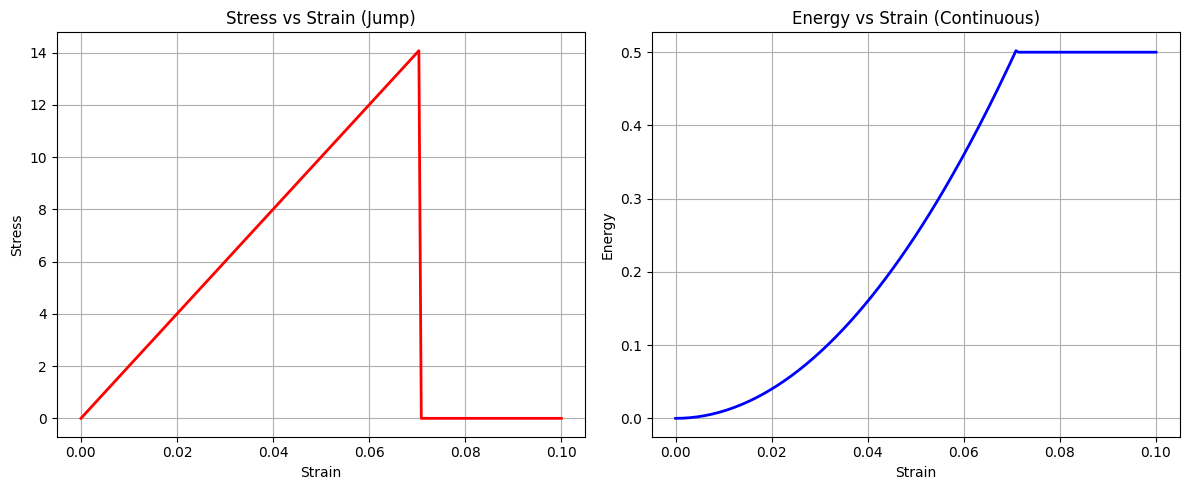

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_1d_fracture():
    # 1. Παράμετροι υλικού
    E = 200.0  # Μέτρο ελαστικότητας (πόσο σκληρό είναι)
    threshold_energy = 0.5  # Το όριο ενέργειας που αντέχει πριν σπάσει

    # 2. Δημιουργία της φόρτισης (τεντώνουμε από 0 έως 0.1)
    strain_steps = np.linspace(0, 0.1, 200)
    stress_history = []
    energy_history = []
    broken = False

    for strain in strain_steps:
        if not broken:
            # Υπολογισμός τάσης (Νόμος του Hooke: σ = Ε * ε)
            current_stress = E * strain
            # Υπολογισμός ενέργειας (U = 0.5 * σ * ε)
            current_energy = 0.5 * current_stress * strain

            # Έλεγχος αν έσπασε
            if current_energy > threshold_energy:
                broken = True
                current_stress = 0 # ΤΟ ΑΛΜΑ ΣΤΟ ΜΗΔΕΝ
        else:
            current_stress = 0
            current_energy = threshold_energy # Η ενέργεια μένει σταθερή (συνεχής)

        stress_history.append(current_stress)
        energy_history.append(current_energy)

    # 3. Εμφάνιση των αποτελεσμάτων
    plt.figure(figsize=(12, 5))

    # Γράφημα Τάσης - Το "Άλμα" (Jump)
    plt.subplot(1, 2, 1)
    plt.plot(strain_steps, stress_history, color='red', linewidth=2)
    plt.title("Stress vs Strain (Jump)")
    plt.xlabel("Strain")
    plt.ylabel("Stress")
    plt.grid(True)

    # Γράφημα Ενέργειας - Η "Συνέχεια" που έλεγε ο καθηγητής
    plt.subplot(1, 2, 2)
    plt.plot(strain_steps, energy_history, color='blue', linewidth=2)
    plt.title("Energy vs Strain (Continuous)")
    plt.xlabel("Strain")
    plt.ylabel("Energy")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

simulate_1d_fracture()

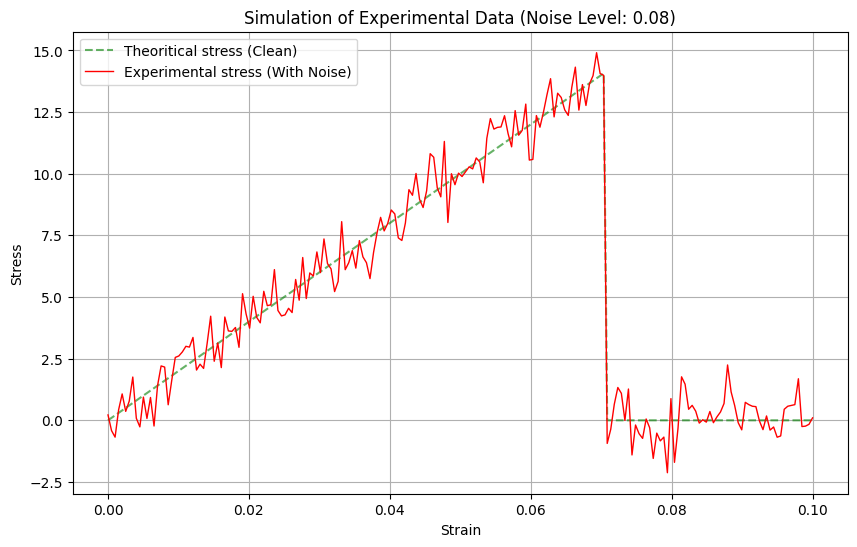

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_experimental_fracture(noise_level=0.05):
    # 1. Παράμετροι υλικού
    E = 200.0
    threshold_energy = 0.5

    # 2. Δημιουργία φόρτισης
    strain_steps = np.linspace(0, 0.1, 200)
    stress_clean = []
    broken = False

    for strain in strain_steps:
        if not broken:
            current_stress = E * strain
            if 0.5 * current_stress * strain > threshold_energy:
                broken = True
                current_stress = 0
        else:
            current_stress = 0
        stress_clean.append(current_stress)

    # 3. ΠΡΟΣΘΗΚΗ ΘΟΡΥΒΟΥ (Noise)
    # Δημιουργούμε τυχαία σφάλματα που εξαρτώνται από το noise_level
    noise = np.random.normal(0, noise_level * E * 0.05, len(stress_clean))
    stress_experimental = np.array(stress_clean) + noise

    # 4. Εμφάνιση των αποτελεσμάτων
    plt.figure(figsize=(10, 6))
    plt.plot(strain_steps, stress_clean, 'g--', label="Theoritical stress (Clean)", alpha=0.6)
    plt.plot(strain_steps, stress_experimental, 'r-', label="Experimental stress (With Noise)", linewidth=1)

    plt.title(f"Simulation of Experimental Data (Noise Level: {noise_level})")
    plt.xlabel("Strain")
    plt.ylabel("Stress")
    plt.legend()
    plt.grid(True)
    plt.show()

# Δοκίμασε να αλλάξεις το noise_level από 0.01 σε 0.2 για να δεις τη διαφορά!
simulate_experimental_fracture(noise_level=0.08)

In [17]:
import numpy as np
import pandas as pd
import random

def create_fracture_dataset(num_samples=100):
    all_data = []

    print(f"start generate {num_samples} samples...")

    for i in range(num_samples):
        # 1. Τυχαίες παράμετροι για κάθε "εικονική ράβδο"
        E = random.uniform(180, 220)           # Μέτρο ελαστικότητας
        threshold = random.uniform(0.3, 0.7)    # Αντοχή στη θραύση

        # 2. Τρέχουμε την προσομοίωση
        strain_steps = np.linspace(0, 0.1, 100)
        broken = False
        breaking_strain = 0.1 # Default αν δεν σπάσει

        for strain in strain_steps:
            current_energy = 0.5 * (E * strain) * strain
            if current_energy > threshold:
                breaking_strain = strain
                broken = True
                break # Σταματάμε μόλις σπάσει

        # 3. Αποθηκεύουμε τα χαρακτηριστικά (Features) και το αποτέλεσμα (Target)
        all_data.append({
            'sample_id': i,
            'elastic_modulus': E,
            'energy_threshold': threshold,
            'breaking_point_strain': breaking_strain, # Αυτό είναι το Target μας
            'is_broken': 1 if broken else 0
        })

    # 4. Μετατροπή σε Pandas DataFrame και αποθήκευση σε CSV
    df = pd.DataFrame(all_data)
    df.to_csv('fracture_data.csv', index=False)

    print("the file 'fracture_data.csv' generated!")
    return df

# Τρέξε το εργοστάσιο
dataset = create_fracture_dataset(100)

# Δείξε μας τις πρώτες 10 γραμμές του πίνακα
print("\n--- 10 first lines of Dataset ---")
print(dataset.head(10))

start generate 100 samples...
the file 'fracture_data.csv' generated!

--- 10 first lines of Dataset ---
   sample_id  elastic_modulus  energy_threshold  breaking_point_strain  \
0          0       188.028222          0.488239               0.072727   
1          1       198.464028          0.463735               0.068687   
2          2       208.528245          0.693214               0.081818   
3          3       209.927729          0.567921               0.073737   
4          4       199.884361          0.681620               0.082828   
5          5       211.921283          0.623848               0.076768   
6          6       214.409111          0.588191               0.074747   
7          7       213.760692          0.409052               0.062626   
8          8       191.731168          0.330233               0.059596   
9          9       191.552191          0.526256               0.074747   

   is_broken  
0          1  
1          1  
2          1  
3          1  
4    

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers

# 1. Φόρτωση των δεδομένων
df = pd.read_csv('fracture_data.csv')

# 2. Επιλογή Features (X) και Target (y)
X = df[['elastic_modulus', 'energy_threshold']].values
y = df['breaking_point_strain'].values

# 3. Διαχωρισμός σε δεδομένα Εκπαίδευσης (80%) και Τεστ (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Κανονικοποίηση (Scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Χτίσιμο του "Εγκεφάλου" (Νευρωνικό Δίκτυο)
model = tf.keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)), # 1ο επίπεδο (16 νευρώνες)
    layers.Dense(8, activation='relu'),                   # 2ο επίπεδο (8 νευρώνες)
    layers.Dense(1)                                       # Έξοδος (η πρόβλεψη)
])

# 6. Μεταγλώττιση
model.compile(optimizer='adam', loss='mse')

# 7. ΕΚΠΑΙΔΕΥΣΗ (Το AI "διαβάζει" το CSV 100 φορές)
print("The training started...")
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0)
print("The training finished!")

# 8. Κάνουμε μια πρόβλεψη για μια ΝΕΑ ράβδο
new_rod = np.array([[210.0, 0.45]]) # Μια ράβδος που δεν είδε ποτέ το AI
new_rod_scaled = scaler.transform(new_rod)
prediction = model.predict(new_rod_scaled)

print(f"\nFor a rod with E=210 and Threshold=0.45:")
print(f"AI predictis the crack to Strain: {prediction[0][0]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The training started...
The training finished!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

For a rod with E=210 and Threshold=0.45:
AI predictis the crack to Strain: 0.0875


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. ΔΗΜΙΟΥΡΓΙΑ ΦΑΣΜΑΤΙΚΩΝ ΔΕΔΟΜΕΝΩΝ (Synthetic Spectral Data)
def generate_spectral_data(samples=1000):
    data = []
    for _ in range(samples):
        # Τυχαία αντοχή
        strength = np.random.uniform(0.5, 1.0)

        # Προσομοιώνουμε 5 ιδιοτιμές (eigenvalues) που πέφτουν καθώς το φορτίο αυξάνεται
        # Όσο πλησιάζουμε στη θραύση (load -> strength), οι τιμές τείνουν στο 0
        current_load = np.random.uniform(0, strength)

        # Μαθηματικό μοντέλο φάσματος: λ_i = (strength - current_load) * i
        eigenvalues = [(strength - current_load) * i for i in range(1, 6)]

        # Πόσο μακριά είμαστε από το σπάσιμο; (Target: Distance to failure)
        distance_to_failure = strength - current_load

        data.append(eigenvalues + [distance_to_failure])

    return pd.DataFrame(data, columns=['eig1', 'eig2', 'eig3', 'eig4', 'eig5', 'target'])

# 2. ΠΡΟΕΤΟΙΜΑΣΙΑ
df = generate_spectral_data()
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. ΤΟ ΝΕΥΡΩΝΙΚΟ ΔΙΚΤΥΟ (Spectral Expert)
model = tf.keras.Sequential([
    layers.Input(shape=(5,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mae')

# 4. ΕΚΠΑΙΔΕΥΣΗ
print(" AI studies eigenvalues...")
model.fit(X_train, y_train, epochs=50, verbose=0)
print("completed!")

# 5. ΤΕΣΤ: Δίνουμε στο AI ένα "περίεργο" φάσμα
sample_spectrum = np.array([[0.1, 0.2, 0.3, 0.4, 0.5]])
prediction = model.predict(sample_spectrum)

print(f"\n--- result of analysis ---")
print(f"eigenvalue entry: {sample_spectrum[0]}")
print(f"prdict AI: the crack will be {prediction[0][0]:.4f} Coulob.")

 AI studies eigenvalues...
completed!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

--- result of analysis ---
eigenvalue entry: [0.1 0.2 0.3 0.4 0.5]
prdict AI: the crack will be 0.1032 Coulob.
